In [6]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns # for making plots with seaborn
color = sns.color_palette()
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

import warnings
warnings.filterwarnings("ignore")

# 1. Introduction - What did you wish to achieve while doing the project ?

#### answer is mentioned in report

In [7]:
cf= pd.read_excel('Customer Churn Data1.xlsx',sheet_name="Meta Data")

# 2. Data Report
a) Understanding how data was collected in terms of time, frequency and methodology

answer is provided in report

In [8]:
cf.head(20)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,NaN,Variable,Description
1,NaN,AccountID,account unique identifier
2,NaN,Churn,account churn flag (Target)
3,NaN,Tenure,Tenure of account
4,NaN,City_Tier,Tier of primary customer's city
5,NaN,CC_Contacted_L12m,How many times all the customers of the accoun...
6,NaN,Payment,Preferred Payment mode of the customers in the...
7,NaN,Gender,Gender of the primary customer of the account
8,NaN,Service_Score,Satisfaction score given by customers of the a...
9,NaN,Account_user_count,Number of customers tagged with this account


# 3. Data Cleaning and Pre-processing - Approach used for identifying and treating missing values and outlier treatment (and why) - Need for variable transformation (if any) - Variables removed or added and why (if any)

In [9]:
df= pd.read_excel('Customer Churn Data1.xlsx',sheet_name="Data for DSBA")


In [10]:
df.head()

,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,20000,1,4,3.0,6.0,Debit Card,Female,3.0,3,Super,2.0,Single,9,1.0,11,1,5,159.93,Mobile
1,20001,1,0,1.0,8.0,UPI,Male,3.0,4,Regular Plus,3.0,Single,7,1.0,15,0,0,120.9,Mobile
2,20002,1,0,1.0,30.0,Debit Card,Male,2.0,4,Regular Plus,3.0,Single,6,1.0,14,0,3,NaN,Mobile
3,20003,1,0,3.0,15.0,Debit Card,Male,2.0,4,Super,5.0,Single,8,0.0,23,0,3,134.07,Mobile
4,20004,1,0,1.0,12.0,Credit Card,Male,2.0,3,Regular Plus,5.0,Single,3,0.0,11,1,3,129.6,Mobile


In [11]:
df.tail()

,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
11255,31255,0,10,1.0,34.0,Credit Card,Male,3.0,2,Super,1.0,Married,9,0.0,19,1,4,153.71,Computer
11256,31256,0,13,1.0,19.0,Credit Card,Male,3.0,5,HNI,5.0,Married,7,0.0,16,1,8,226.91,Mobile
11257,31257,0,1,1.0,14.0,Debit Card,Male,3.0,2,Super,4.0,Married,7,1.0,22,1,4,191.42,Mobile
11258,31258,0,23,3.0,11.0,Credit Card,Male,4.0,5,Super,4.0,Married,7,0.0,16,2,9,179.9,Computer
11259,31259,0,8,1.0,22.0,Credit Card,Male,3.0,2,Super,3.0,Married,5,0.0,13,2,3,175.04,Mobile


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AccountID                11260 non-null  int64  
 1   Churn                    11260 non-null  int64  
 2   Tenure                   11158 non-null  object 
 3   City_Tier                11148 non-null  float64
 4   CC_Contacted_LY          11158 non-null  float64
 5   Payment                  11151 non-null  object 
 6   Gender                   11152 non-null  object 
 7   Service_Score            11162 non-null  float64
 8   Account_user_count       11148 non-null  object 
 9   account_segment          11163 non-null  object 
 10  CC_Agent_Score           11144 non-null  float64
 11  Marital_Status           11048 non-null  object 
 12  rev_per_month            11158 non-null  object 
 13  Complain_ly              10903 non-null  float64
 14  rev_growth_yoy        

### b) Visual inspection of data (rows, columns, descriptive details)

In [13]:

df.shape

(11260, 19)

In [14]:
df.columns.values

array(['AccountID', 'Churn', 'Tenure', 'City_Tier', 'CC_Contacted_LY',
       'Payment', 'Gender', 'Service_Score', 'Account_user_count',
       'account_segment', 'CC_Agent_Score', 'Marital_Status',
       'rev_per_month', 'Complain_ly', 'rev_growth_yoy',
       'coupon_used_for_payment', 'Day_Since_CC_connect', 'cashback',
       'Login_device'], dtype=object)

In [15]:
df.size

213940

In [16]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
AccountID,11260.0,NaN,NaN,NaN,25629.5,3250.62635,20000.0,22814.75,25629.5,28444.25,31259.0
Churn,11260.0,NaN,NaN,NaN,0.168384,0.374223,0.0,0.0,0.0,0.0,1.0
Tenure,11158.0,38.0,1.0,1351.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City_Tier,11148.0,NaN,NaN,NaN,1.653929,0.915015,1.0,1.0,1.0,3.0,3.0
CC_Contacted_LY,11158.0,NaN,NaN,NaN,17.867091,8.853269,4.0,11.0,16.0,23.0,132.0
Payment,11151,5,Debit Card,4587,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,11152,4,Male,6328,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Service_Score,11162.0,NaN,NaN,NaN,2.902526,0.725584,0.0,2.0,3.0,3.0,5.0
Account_user_count,11148.0,7.0,4.0,4569.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
account_segment,11163,7,Super,4062,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### c) Understanding of attributes (variable info, renaming if required)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AccountID                11260 non-null  int64  
 1   Churn                    11260 non-null  int64  
 2   Tenure                   11158 non-null  object 
 3   City_Tier                11148 non-null  float64
 4   CC_Contacted_LY          11158 non-null  float64
 5   Payment                  11151 non-null  object 
 6   Gender                   11152 non-null  object 
 7   Service_Score            11162 non-null  float64
 8   Account_user_count       11148 non-null  object 
 9   account_segment          11163 non-null  object 
 10  CC_Agent_Score           11144 non-null  float64
 11  Marital_Status           11048 non-null  object 
 12  rev_per_month            11158 non-null  object 
 13  Complain_ly              10903 non-null  float64
 14  rev_growth_yoy        

In [18]:
df.Tenure = df.Tenure.replace(to_replace = '#', value =0)
df.rev_per_month = df.rev_per_month.replace(to_replace = '+', value =0)
df.cashback = df.cashback.replace(to_replace = '$', value =0)
df.Account_user_count = df.Account_user_count.replace(to_replace = '@', value =0)
df.Day_Since_CC_connect = df.Day_Since_CC_connect.replace(to_replace = '$', value =0)
df.coupon_used_for_payment = df.coupon_used_for_payment.replace(to_replace = '*', value =0)
df.coupon_used_for_payment = df.coupon_used_for_payment.replace(to_replace = '$', value =0)
df.coupon_used_for_payment = df.coupon_used_for_payment.replace(to_replace = '#', value =.0)
df.rev_growth_yoy= df.rev_growth_yoy.replace(to_replace = '$', value =0)

Feature: 0, Score: 49.47500
Feature: 1, Score: 0.00000
Feature: 2, Score: -0.00000
Feature: 3, Score: -0.00000
Feature: 4, Score: 0.00000
Feature: 5, Score: 0.00000
Feature: 6, Score: 0.00000
Feature: 7, Score: -0.00000
Feature: 8, Score: -0.00000
Feature: 9, Score: 46.40216
Feature: 10, Score: 79.33023
Feature: 11, Score: 97.14084
Feature: 12, Score: 0.00000
Feature: 13, Score: -0.00000
Feature: 14, Score: 0.00000
Feature: 15, Score: 2.54289
Feature: 16, Score: 0.00000
Feature: 17, Score: -0.00000


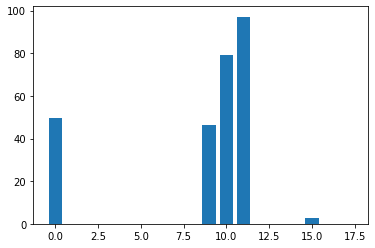

In [19]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot
# define dataset
X, y = make_regression(n_samples=1000, n_features=18, n_informative=5, random_state=1)
# define the model
model = LinearRegression()
# fit the model
model.fit(X, y)
# get importance
importance = model.coef_
# summarize feature importance
for i,v in enumerate(importance):
	print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

In [20]:

df['Tenure']=df['Tenure'].astype(str).astype(float)

In [21]:
df.skew()

AccountID                  0.000000
Churn                      1.772606
Tenure                     3.891973
City_Tier                  0.737107
CC_Contacted_LY            1.422977
Service_Score              0.003891
Account_user_count        -0.861867
CC_Agent_Score            -0.142149
rev_per_month              9.236700
Complain_ly                0.950876
rev_growth_yoy             0.729281
coupon_used_for_payment    2.575218
Day_Since_CC_connect       1.272969
cashback                   8.769003
dtype: float64

In [22]:
df.isnull().sum()

AccountID                    0
Churn                        0
Tenure                     102
City_Tier                  112
CC_Contacted_LY            102
Payment                    109
Gender                     108
Service_Score               98
Account_user_count         112
account_segment             97
CC_Agent_Score             116
Marital_Status             212
rev_per_month              102
Complain_ly                357
rev_growth_yoy               0
coupon_used_for_payment      0
Day_Since_CC_connect       357
cashback                   471
Login_device               221
dtype: int64

### 3 a) Removal of unwanted variables (if applicable) 

In [23]:
df = df.drop(["AccountID"], axis=1)
df.head()

,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,1,4.0,3.0,6.0,Debit Card,Female,3.0,3.0,Super,2.0,Single,9.0,1.0,11,1.0,5.0,159.93,Mobile
1,1,0.0,1.0,8.0,UPI,Male,3.0,4.0,Regular Plus,3.0,Single,7.0,1.0,15,0.0,0.0,120.90,Mobile
2,1,0.0,1.0,30.0,Debit Card,Male,2.0,4.0,Regular Plus,3.0,Single,6.0,1.0,14,0.0,3.0,NaN,Mobile
3,1,0.0,3.0,15.0,Debit Card,Male,2.0,4.0,Super,5.0,Single,8.0,0.0,23,0.0,3.0,134.07,Mobile
4,1,0.0,1.0,12.0,Credit Card,Male,2.0,3.0,Regular Plus,5.0,Single,3.0,0.0,11,1.0,3.0,129.60,Mobile


### b) Missing Value treatment (if applicable)

In [24]:
df.isnull().sum()

Churn                        0
Tenure                     102
City_Tier                  112
CC_Contacted_LY            102
Payment                    109
Gender                     108
Service_Score               98
Account_user_count         112
account_segment             97
CC_Agent_Score             116
Marital_Status             212
rev_per_month              102
Complain_ly                357
rev_growth_yoy               0
coupon_used_for_payment      0
Day_Since_CC_connect       357
cashback                   471
Login_device               221
dtype: int64

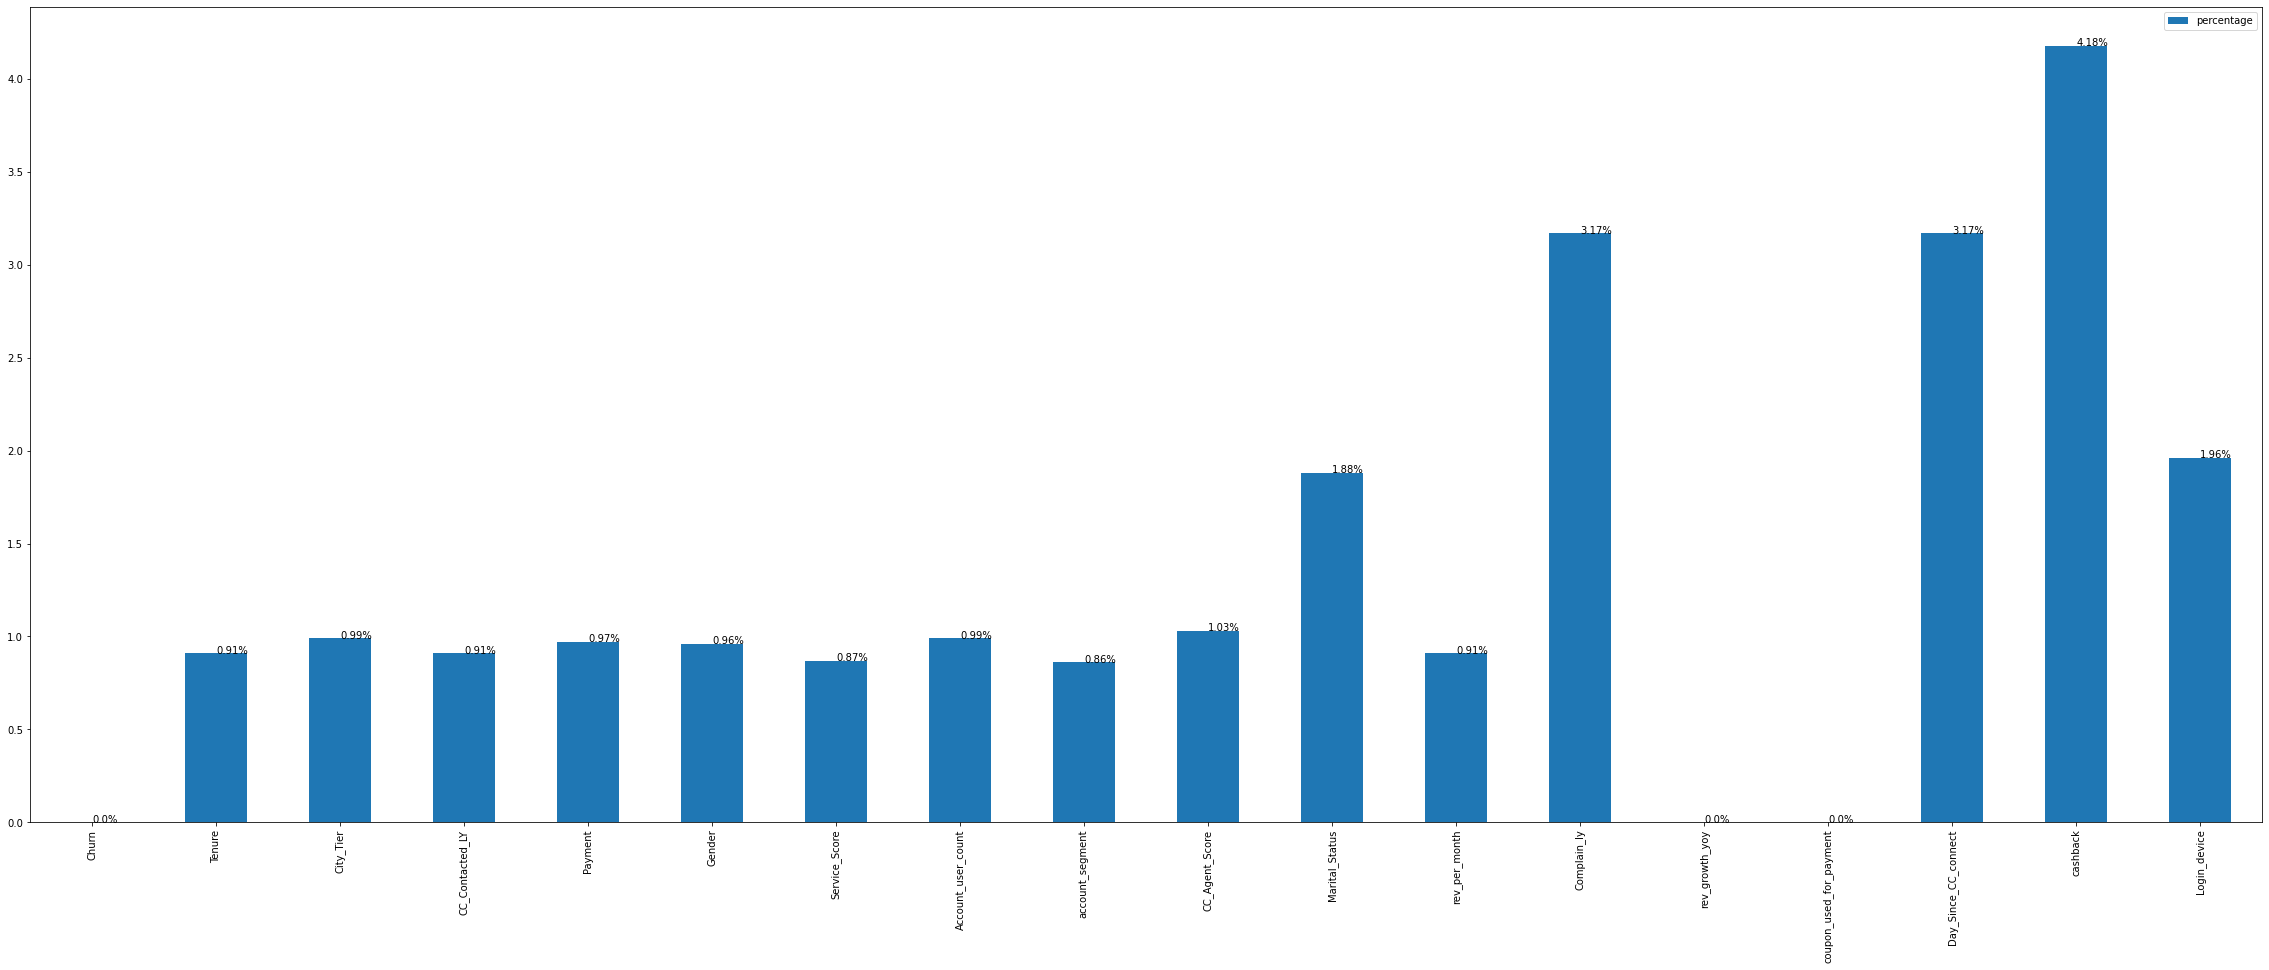

In [25]:
missing_count_df = df.isnull().sum() # the count of missing value
value_count_df = df.isnull().count() # the count of all values
missing_percentage_df = round(missing_count_df/value_count_df*100,2) # the percentage of missing values
missing_df = pd.DataFrame({'count' : missing_count_df, 'percentage' : missing_percentage_df }) # create a dataframe
barchart = missing_df.plot.bar(y='percentage',rot=90,figsize=(40,15))
for index, percentage in enumerate(missing_percentage_df):
    barchart.text(index,percentage,str(percentage) + '%')

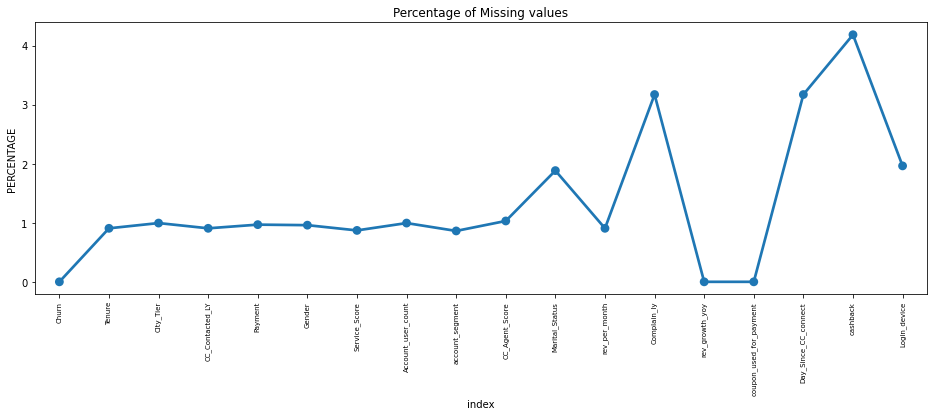

In [26]:
missing = pd.DataFrame((df.isnull().sum())*100/df.shape[0]).reset_index()
plt.figure(figsize=(16,5))
ax = sns.pointplot('index',0,data=missing)
plt.xticks(rotation =90,fontsize =7)
plt.title("Percentage of Missing values")
plt.ylabel("PERCENTAGE")
plt.show()

In [27]:
df['CC_Contacted_LY'] = df['CC_Contacted_LY'].fillna(df['CC_Contacted_LY'].median())
df['Service_Score'] = df['Service_Score'].fillna(df['Service_Score'].median())
df['City_Tier'] = df['City_Tier'].fillna(df['City_Tier'].median())
df['CC_Agent_Score'] = df['CC_Agent_Score'].fillna(df['CC_Agent_Score'].median())
df['Complain_ly'] = df['Complain_ly'].fillna(df['Complain_ly'].median())

In [28]:
df['Tenure'] = df['Tenure'].fillna("0")
df['Payment'] = df['Payment'].fillna("0")
df['Gender'] = df['Gender'].fillna("0")
df['Account_user_count'] = df['Account_user_count'].fillna(0)
df['account_segment'] = df['account_segment'].fillna("0")
df['Marital_Status'] = df['Marital_Status'].fillna("0")
df['rev_per_month'] = df['rev_per_month'].fillna(0)
df['Day_Since_CC_connect'] = df['Day_Since_CC_connect'].fillna(0)
df['cashback'] = df['cashback'].fillna(0)
df['Login_device'] = df['Login_device'].fillna("0")

In [29]:
df.isnull().sum()

Churn                      0
Tenure                     0
City_Tier                  0
CC_Contacted_LY            0
Payment                    0
Gender                     0
Service_Score              0
Account_user_count         0
account_segment            0
CC_Agent_Score             0
Marital_Status             0
rev_per_month              0
Complain_ly                0
rev_growth_yoy             0
coupon_used_for_payment    0
Day_Since_CC_connect       0
cashback                   0
Login_device               0
dtype: int64

In [30]:
df.duplicated().sum()

260

In [31]:
for column in df.columns:
    if df[column].dtype == 'object':
        print(column.upper(),': ',df[column].nunique())
        print(df[column].value_counts().sort_values())
        print('\n')

TENURE :  38
61.0       2
50.0       2
60.0       2
51.0       2
31.0      96
0        102
25.0     114
29.0     114
26.0     122
99.0     131
27.0     131
28.0     137
30.0     137
24.0     147
22.0     151
23.0     169
21.0     170
17.0     215
20.0     217
18.0     253
19.0     273
16.0     291
15.0     311
14.0     345
2.0      354
13.0     359
12.0     360
6.0      363
11.0     388
5.0      403
4.0      403
3.0      410
10.0     423
7.0      450
9.0      496
8.0      519
0.0     1347
1.0     1351
Name: Tenure, dtype: int64


PAYMENT :  6
0                    109
UPI                  822
Cash on Delivery    1014
E wallet            1217
Credit Card         3511
Debit Card          4587
Name: Payment, dtype: int64


GENDER :  5
0          108
F          270
M          376
Female    4178
Male      6328
Name: Gender, dtype: int64


ACCOUNT_SEGMENT :  8
Super +           47
0                 97
Regular +        262
Regular          520
Super Plus       771
HNI             1639
Regular 

In [32]:
df.head()

,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,1,4.0,3.0,6.0,Debit Card,Female,3.0,3.0,Super,2.0,Single,9.0,1.0,11,1.0,5.0,159.93,Mobile
1,1,0.0,1.0,8.0,UPI,Male,3.0,4.0,Regular Plus,3.0,Single,7.0,1.0,15,0.0,0.0,120.90,Mobile
2,1,0.0,1.0,30.0,Debit Card,Male,2.0,4.0,Regular Plus,3.0,Single,6.0,1.0,14,0.0,3.0,0.00,Mobile
3,1,0.0,3.0,15.0,Debit Card,Male,2.0,4.0,Super,5.0,Single,8.0,0.0,23,0.0,3.0,134.07,Mobile
4,1,0.0,1.0,12.0,Credit Card,Male,2.0,3.0,Regular Plus,5.0,Single,3.0,0.0,11,1.0,3.0,129.60,Mobile


In [33]:
df.Gender=df.Gender.str.replace('Female', 'F')
df.Gender = df.Gender.str.replace('Male', 'M')


In [34]:
for column in df.columns:
    if df[column].dtype == 'object':
        print(column.upper(),': ',df[column].nunique())
        print(df[column].value_counts().sort_values())
        print('\n')

TENURE :  38
61.0       2
50.0       2
60.0       2
51.0       2
31.0      96
0        102
25.0     114
29.0     114
26.0     122
99.0     131
27.0     131
28.0     137
30.0     137
24.0     147
22.0     151
23.0     169
21.0     170
17.0     215
20.0     217
18.0     253
19.0     273
16.0     291
15.0     311
14.0     345
2.0      354
13.0     359
12.0     360
6.0      363
11.0     388
5.0      403
4.0      403
3.0      410
10.0     423
7.0      450
9.0      496
8.0      519
0.0     1347
1.0     1351
Name: Tenure, dtype: int64


PAYMENT :  6
0                    109
UPI                  822
Cash on Delivery    1014
E wallet            1217
Credit Card         3511
Debit Card          4587
Name: Payment, dtype: int64


GENDER :  3
0     108
F    4448
M    6704
Name: Gender, dtype: int64


ACCOUNT_SEGMENT :  8
Super +           47
0                 97
Regular +        262
Regular          520
Super Plus       771
HNI             1639
Regular Plus    3862
Super           4062
Name: accou

In [35]:
# Are there any duplicates ?
dups = df.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))
df[dups].head(2)

Number of duplicate rows = 271


,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
1347,1,0.0,1.0,8.0,UPI,M,3.0,4.0,Regular Plus,3.0,Single,7.0,1.0,15,0.0,0.0,120.90,Mobile
1395,1,11.0,1.0,6.0,Debit Card,M,3.0,4.0,HNI,3.0,Single,10.0,1.0,13,0.0,0.0,153.81,Mobile


# 2. EDA - Uni-variate / Bi-variate / Multi-variate analysis to understand relationship b/w variables. - Both visual and non-visual understanding of the data.


### a) Univariate analysis (distribution and spread for every continuous attribute, distribution of data in categories for categorical ones)

# EDA

# Univariate Analysis

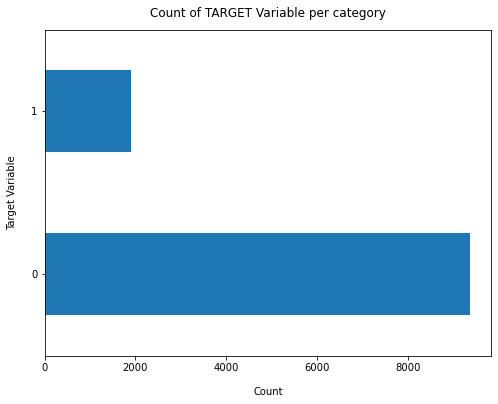

In [147]:
df['Churn'].value_counts().plot(kind='barh', figsize=(8, 6))
plt.xlabel("Count", labelpad=14)
plt.ylabel("Target Variable", labelpad=14)
plt.title("Count of TARGET Variable per category", y=1.02);

In [148]:
100*df['Churn'].value_counts()/len(df['Churn'])

0    83.161634
1    16.838366
Name: Churn, dtype: float64

In [149]:
df['Churn'].value_counts()

0    9364
1    1896
Name: Churn, dtype: int64

In [150]:
df['Gender'].value_counts()

M    6704
F    4448
0     108
Name: Gender, dtype: int64

In [151]:
df['Payment'].value_counts()

Debit Card          4587
Credit Card         3511
E wallet            1217
Cash on Delivery    1014
UPI                  822
0                    109
Name: Payment, dtype: int64

In [152]:
df['Marital_Status'].value_counts()

Married     5860
Single      3520
Divorced    1668
0            212
Name: Marital_Status, dtype: int64

### d) Outlier treatment (if required) 

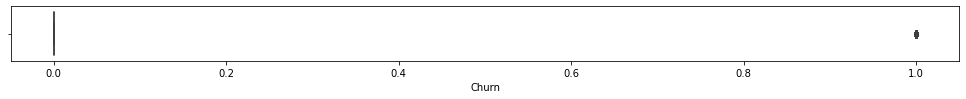

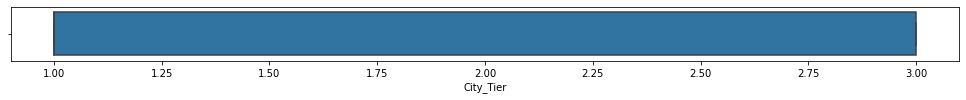

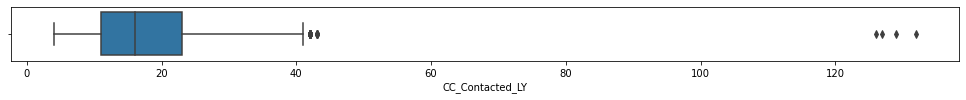

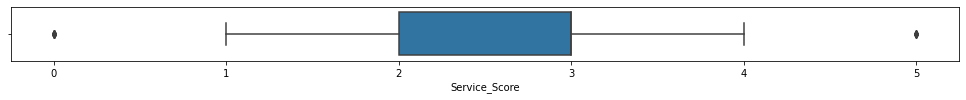

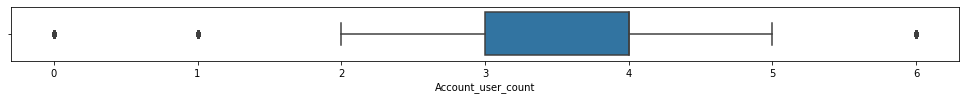

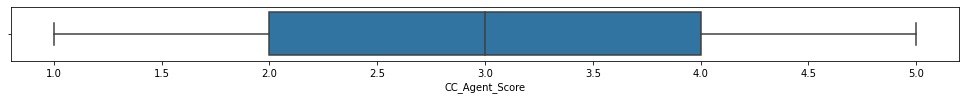

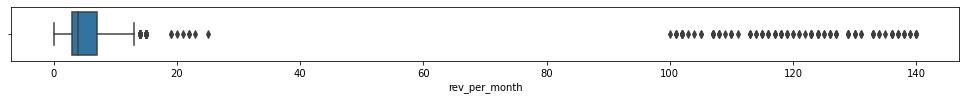

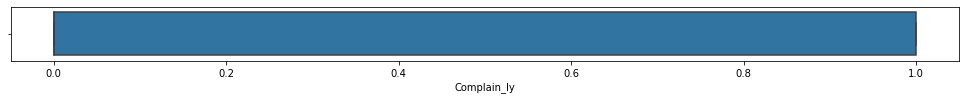

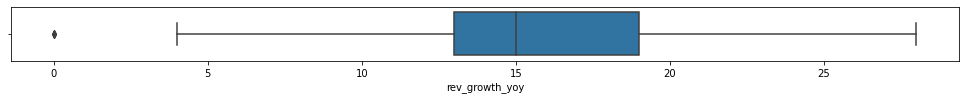

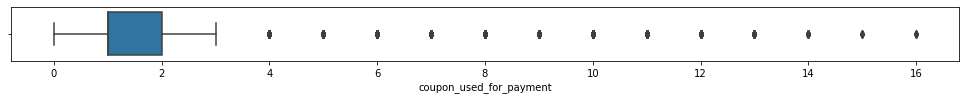

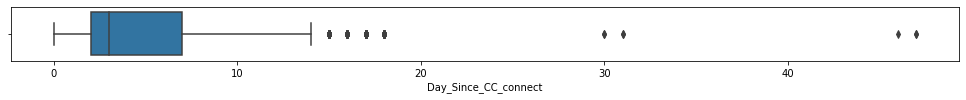

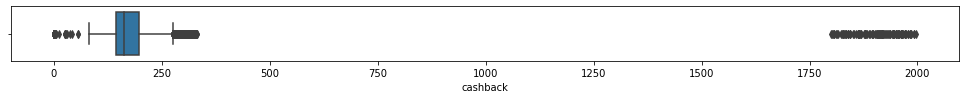

In [153]:
df1=df.select_dtypes(exclude=['object','bool'])
for column in df1:
        plt.figure(figsize=(17,1))
        sns.boxplot(data=df1, x=column)
plt.show()

Index(['Churn', 'City_Tier', 'CC_Contacted_LY', 'Service_Score',
       'Account_user_count', 'CC_Agent_Score', 'rev_per_month', 'Complain_ly',
       'rev_growth_yoy', 'coupon_used_for_payment', 'Day_Since_CC_connect',
       'cashback'],
      dtype='object')


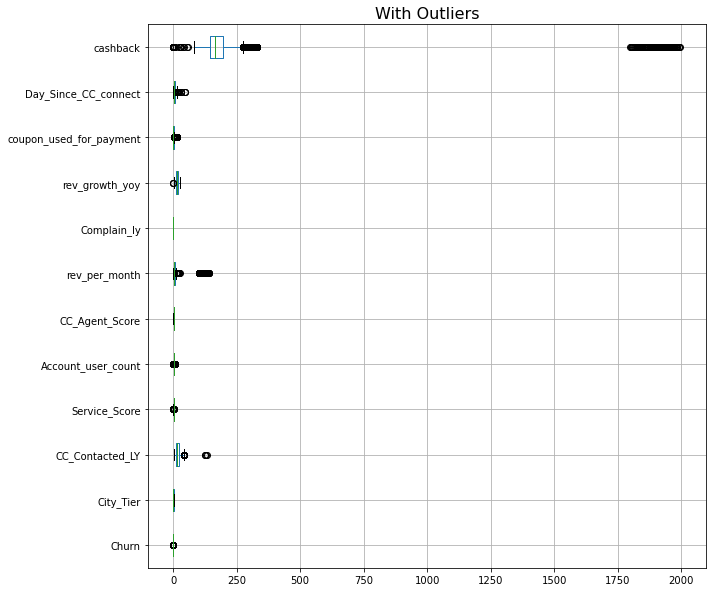

In [154]:
# construct box plot for continuous variables
cont=df.dtypes[(df.dtypes!='object') & (df.dtypes!='bool')].index
print(cont)
plt.figure(figsize=(10,10))
df[cont].boxplot(vert=0)
plt.title('With Outliers',fontsize=16)
plt.show()

In [155]:
def remove_outlier(col):
    sorted(col)
    Q1,Q3=np.percentile(col,[25,75])
    IQR=Q3-Q1
    lower_range= Q1-(1.5 * IQR)
    upper_range= Q3+(1.5 * IQR)
    return lower_range, upper_range

In [156]:
for column in df[cont].columns:
    lr,ur=remove_outlier(df[column])
    df[column]=np.where(df[column]>ur,ur,df[column])
    df[column]=np.where(df[column]<lr,lr,df[column])

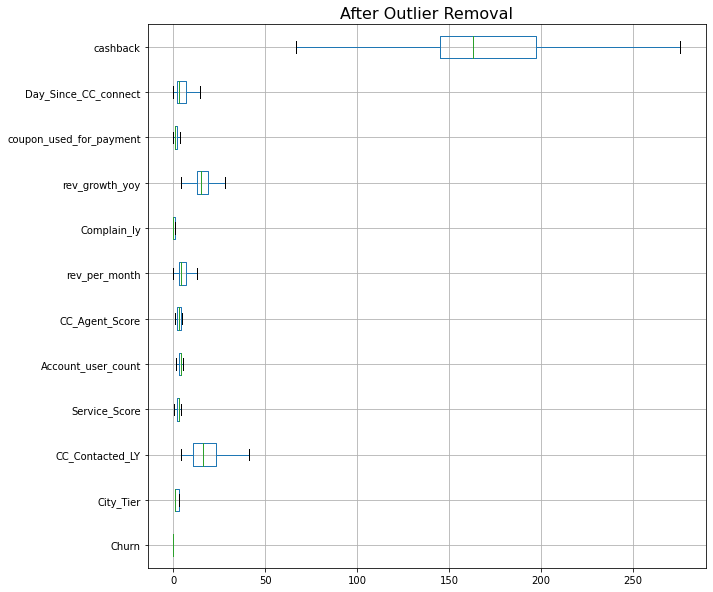

In [157]:
plt.figure(figsize=(10,10))
df[cont].boxplot(vert=0)
plt.title('After Outlier Removal',fontsize=16)
plt.show()

<Figure size 1224x72 with 0 Axes>

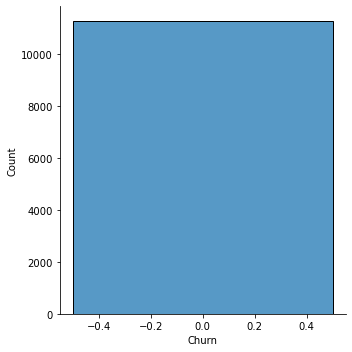

<Figure size 1224x72 with 0 Axes>

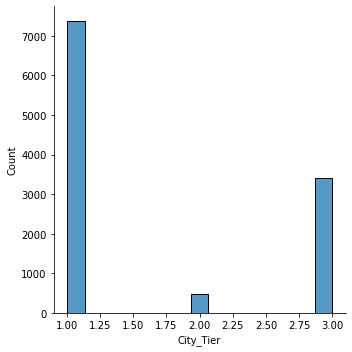

<Figure size 1224x72 with 0 Axes>

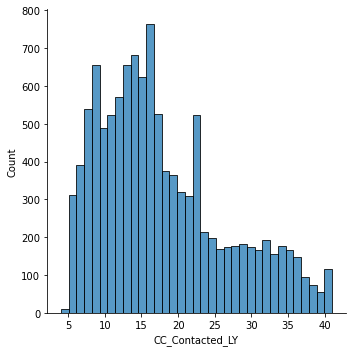

<Figure size 1224x72 with 0 Axes>

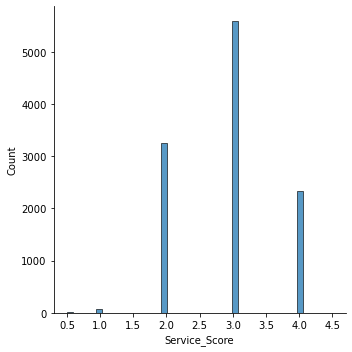

<Figure size 1224x72 with 0 Axes>

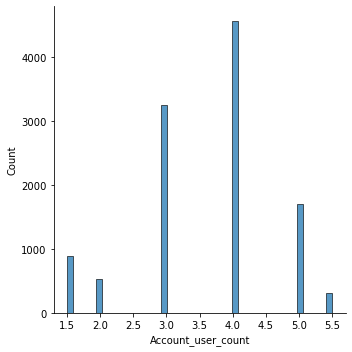

<Figure size 1224x72 with 0 Axes>

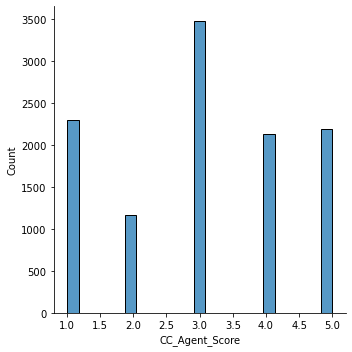

<Figure size 1224x72 with 0 Axes>

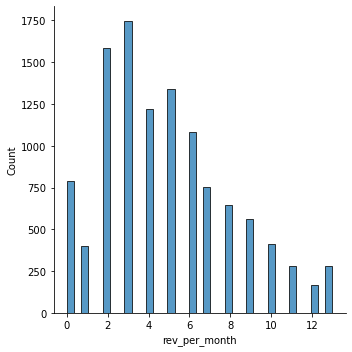

<Figure size 1224x72 with 0 Axes>

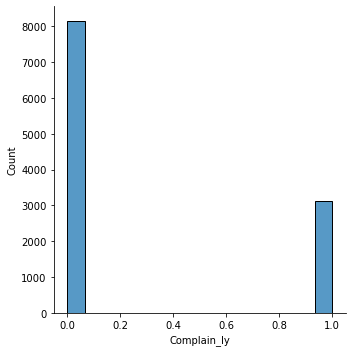

<Figure size 1224x72 with 0 Axes>

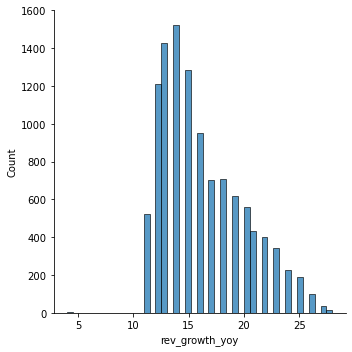

<Figure size 1224x72 with 0 Axes>

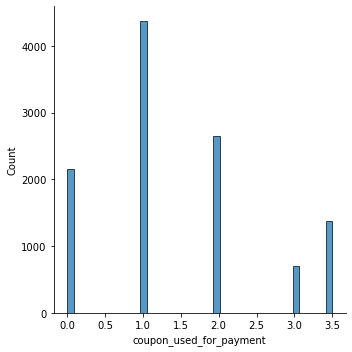

<Figure size 1224x72 with 0 Axes>

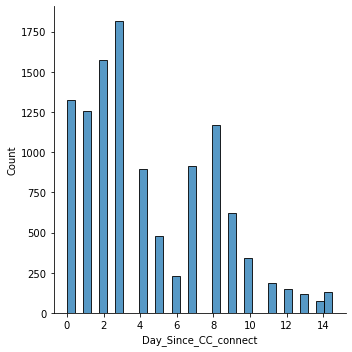

<Figure size 1224x72 with 0 Axes>

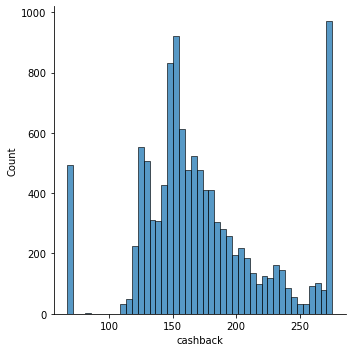

In [158]:
#Printing displot for each numerical column present in the data set
df1=df.select_dtypes(exclude=['object','bool'])
for column in df1:
        plt.figure(figsize=(17,1))
        sns.displot(data=df1, x=column)
plt.show()



In [159]:
categorical_features = ['Gender', 'Marital_Status', 'City_Tier','Service_Score','account_segment','Payment','Login_device','CC_Agent_Score','Complain_ly']

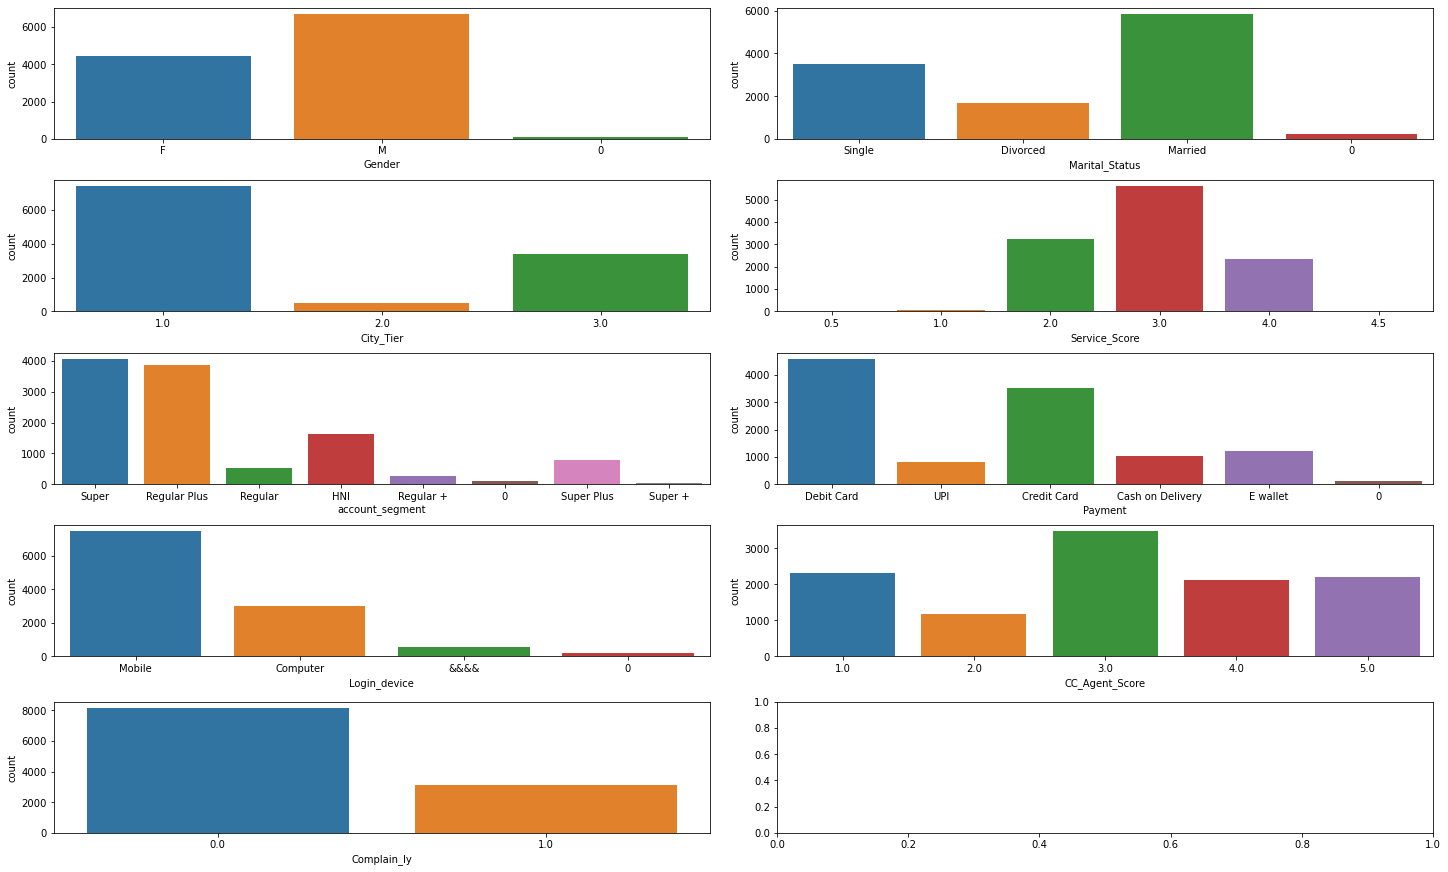

In [160]:
num_plots = len(categorical_features)
total_cols = 2
total_rows = num_plots//total_cols + 1
fig, axs = plt.subplots(nrows=total_rows, ncols=total_cols,
                        figsize=(20,12), facecolor='w', constrained_layout=True)
for i, var in enumerate(categorical_features):
    row = i//total_cols
    pos = i % total_cols
    plot = sns.countplot(x=var, data=df, ax=axs[row][pos])

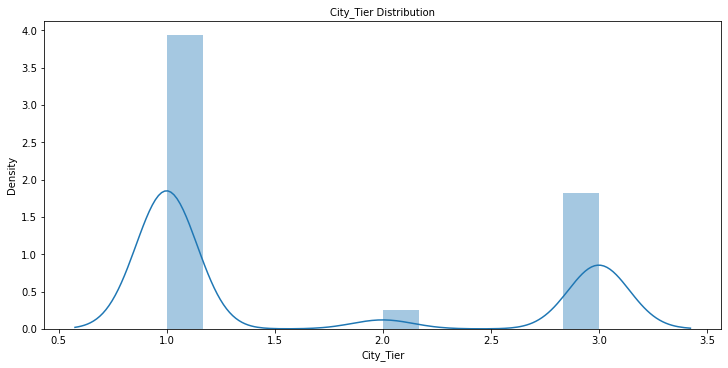

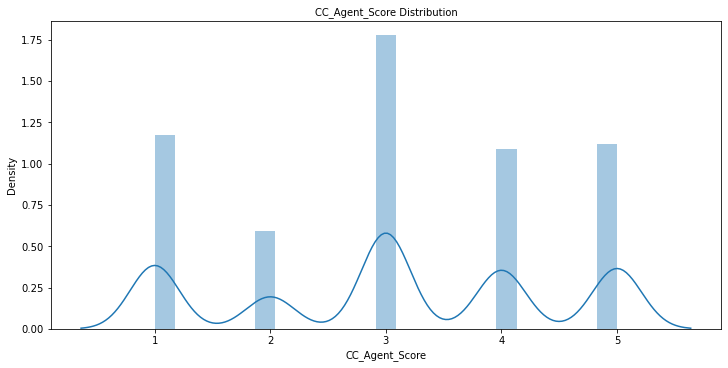

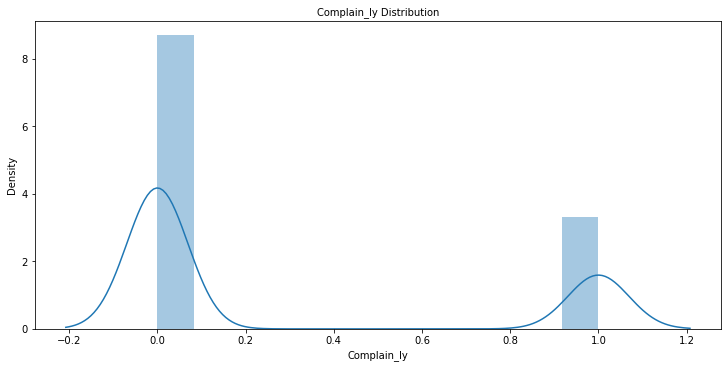

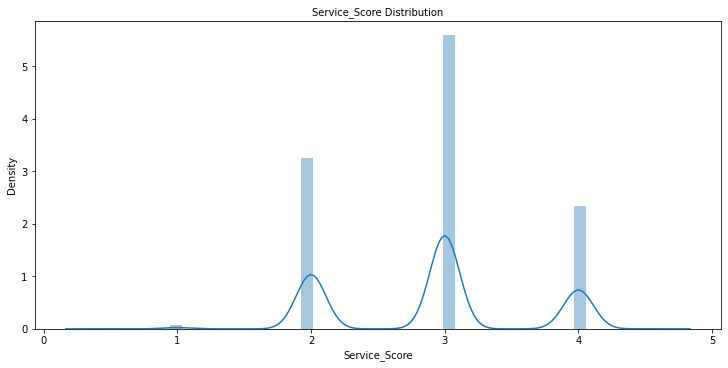

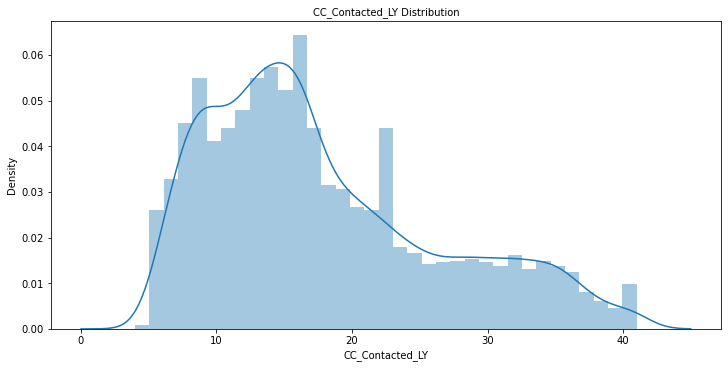

In [161]:
numeric_features = ['City_Tier', 'CC_Agent_Score', 'Complain_ly', 'Service_Score', 'CC_Contacted_LY']
for feature in numeric_features:
    plt.figure(figsize=(10, 5), facecolor='w', constrained_layout=True)
    sns.distplot(df[feature])
    plt.title('{} Distribution'.format(feature), fontsize=10)
    plt.show()

### b) Bivariate analysis (relationship between different variables , correlations) 

# bivariate analysis

In [162]:
df.corr()

,Churn,City_Tier,CC_Contacted_LY,Service_Score,Account_user_count,CC_Agent_Score,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback
Churn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City_Tier,NaN,1.000000,0.006994,-0.007774,0.026983,-0.012175,-0.020169,0.002799,-0.029849,0.025236,0.017723,0.064337
CC_Contacted_LY,NaN,0.006994,1.000000,0.062864,0.014985,0.005100,0.057827,0.029975,0.073725,0.009976,0.017405,0.016594
Service_Score,NaN,-0.007774,0.062864,1.000000,0.288199,0.032011,0.114650,0.003359,0.104062,0.276239,0.101599,0.134107
Account_user_count,NaN,0.026983,0.014985,0.288199,1.000000,-0.009204,0.152041,-0.000213,0.058414,0.190421,0.032153,0.099785
CC_Agent_Score,NaN,-0.012175,0.005100,0.032011,-0.009204,1.000000,0.040359,-0.031649,-0.026964,0.019309,0.024979,0.004762
rev_per_month,NaN,-0.020169,0.057827,0.114650,0.152041,0.040359,1.000000,0.009779,0.052445,0.060170,-0.053641,0.124271
Complain_ly,NaN,0.002799,0.029975,0.003359,-0.000213,-0.031649,0.009779,1.000000,-0.002087,-0.006911,-0.039103,-0.006282
rev_growth_yoy,NaN,-0.029849,0.073725,0.104062,0.058414,-0.026964,0.052445,-0.002087,1.000000,0.054299,0.006364,0.015778
coupon_used_for_payment,NaN,0.025236,0.009976,0.276239,0.190421,0.019309,0.060170,-0.006911,0.054299,1.000000,0.338022,0.243047


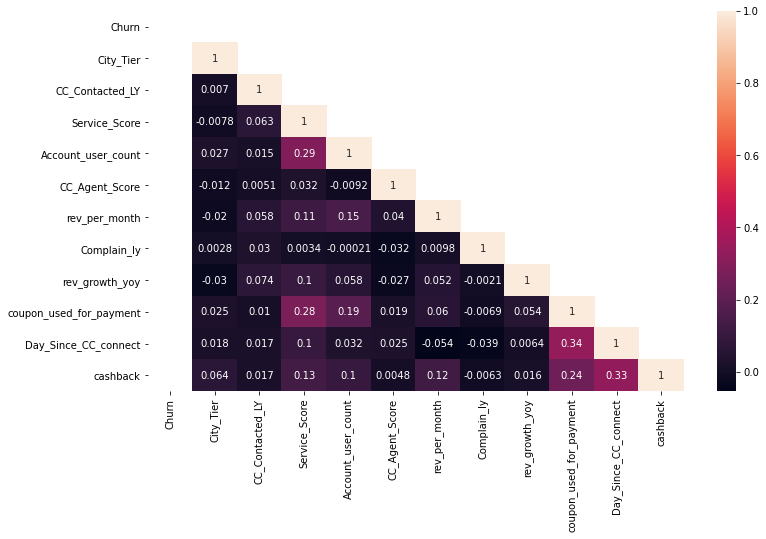

In [163]:
plt.figure(figsize=(12,7))
sns.heatmap(df.corr(), annot=True,mask=np.triu(df.corr(),+1));

<AxesSubplot:xlabel='City_Tier', ylabel='Service_Score'>

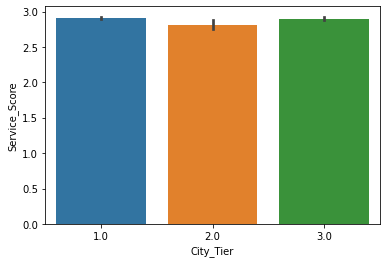

In [119]:
sns.barplot(x='City_Tier',y='Service_Score',data=df)

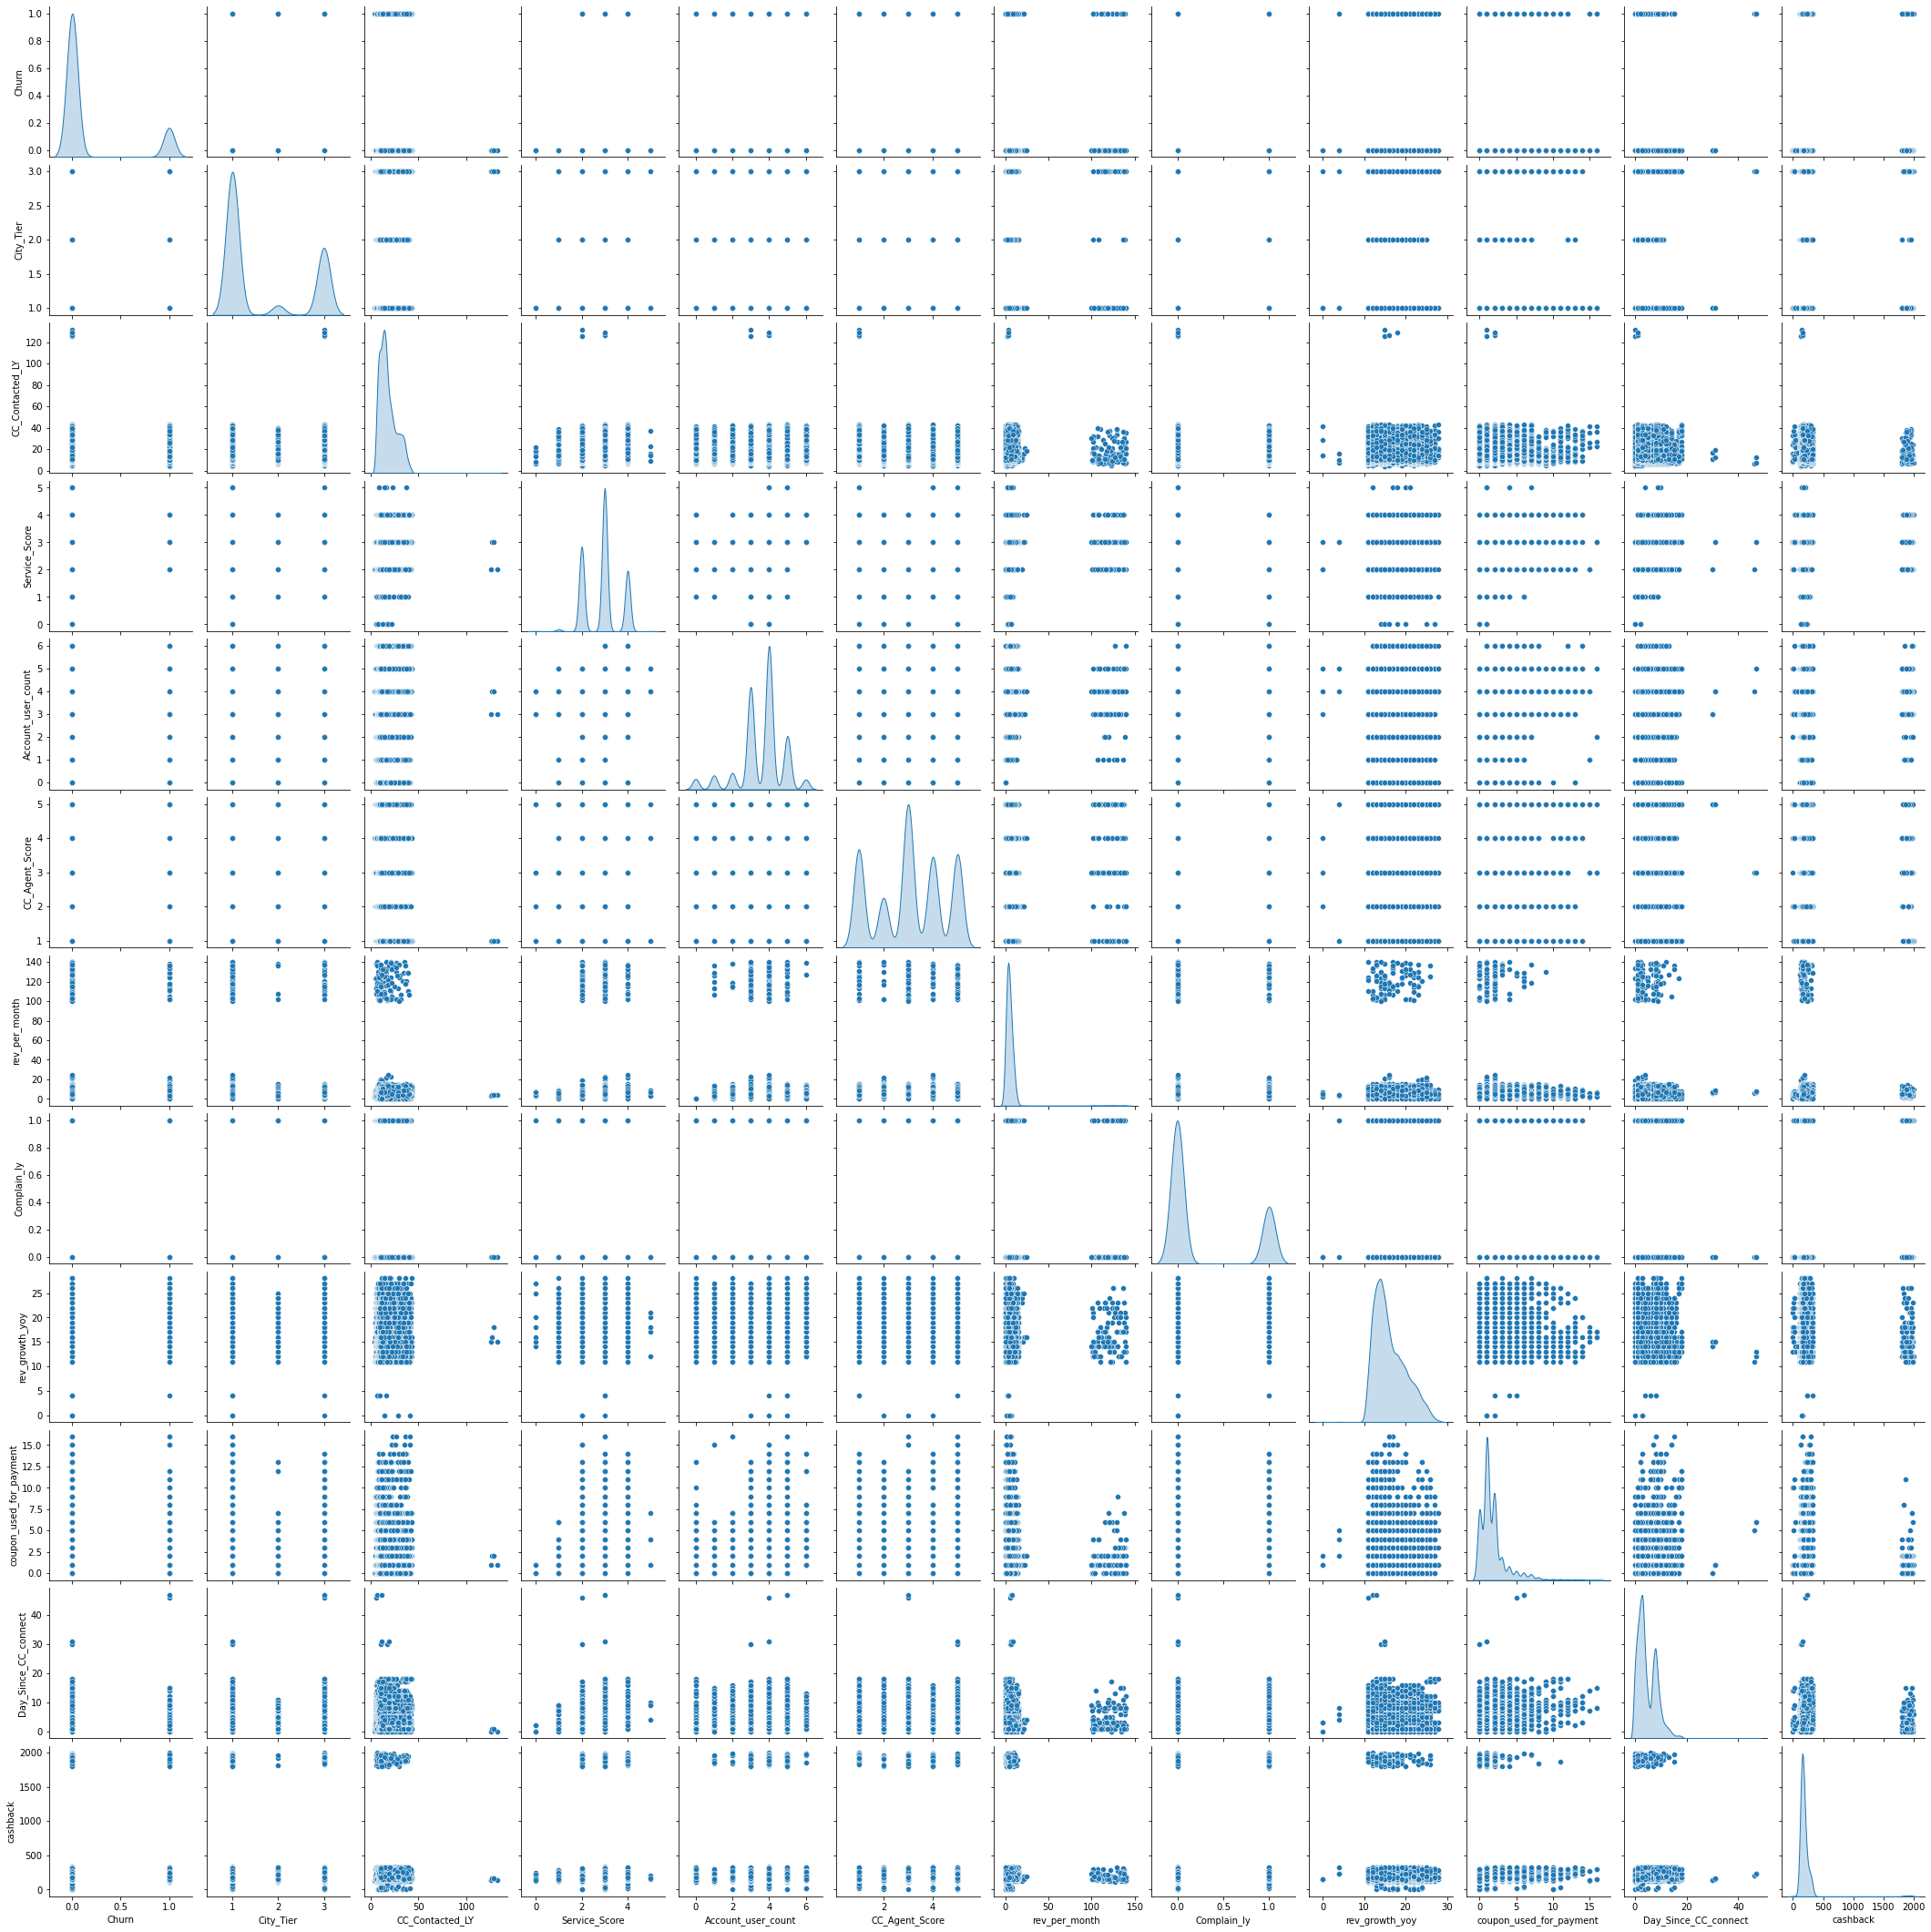

In [120]:
df = (df[cont])
sns.pairplot(df, diag_kind='kde')  
plt.show()

The insights are as follow:
1	Customers with married status are important for the company.
2	If we provide some offer with the UPI payment then it will increase the customer mobility so UPI payment method scale will increase.
3	More focus should be needed for city tier 2 as this is minimum in graph.
4	We should have to work on the quality of service to get the score in the range of 4.5 because this portion is almost negligible.
5	Super plus segment should be increased as it is less compare to other segment. 
 


In [46]:
df.head(10)

,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,1,4.0,3.0,6.0,3,1,3.0,3.0,5,2.0,3,9.0,1.0,11,1.0,5.0,159.93,3
1,1,0.0,1.0,8.0,5,2,3.0,4.0,4,3.0,3,7.0,1.0,15,0.0,0.0,120.90,3
2,1,0.0,1.0,30.0,3,2,2.0,4.0,4,3.0,3,6.0,1.0,14,0.0,3.0,0.00,3
3,1,0.0,3.0,15.0,3,2,2.0,4.0,5,5.0,3,8.0,0.0,23,0.0,3.0,134.07,3
4,1,0.0,1.0,12.0,2,2,2.0,3.0,4,5.0,3,3.0,0.0,11,1.0,3.0,129.60,3
5,1,0.0,1.0,22.0,3,1,3.0,0.0,4,5.0,3,2.0,1.0,22,4.0,7.0,139.19,2
6,1,2.0,3.0,11.0,1,2,2.0,3.0,5,2.0,1,4.0,0.0,14,0.0,0.0,120.86,3
7,1,0.0,1.0,6.0,2,2,3.0,3.0,4,2.0,1,3.0,1.0,16,2.0,0.0,122.93,3
8,1,13.0,3.0,9.0,4,2,2.0,4.0,4,3.0,1,2.0,1.0,14,0.0,2.0,126.83,3
9,1,0.0,1.0,31.0,3,2,2.0,5.0,4,3.0,3,2.0,0.0,12,1.0,1.0,122.93,3


Feature: 0, Score: 49.47500
Feature: 1, Score: 0.00000
Feature: 2, Score: -0.00000
Feature: 3, Score: -0.00000
Feature: 4, Score: 0.00000
Feature: 5, Score: 0.00000
Feature: 6, Score: 0.00000
Feature: 7, Score: -0.00000
Feature: 8, Score: -0.00000
Feature: 9, Score: 46.40216
Feature: 10, Score: 79.33023
Feature: 11, Score: 97.14084
Feature: 12, Score: 0.00000
Feature: 13, Score: -0.00000
Feature: 14, Score: 0.00000
Feature: 15, Score: 2.54289
Feature: 16, Score: 0.00000
Feature: 17, Score: -0.00000


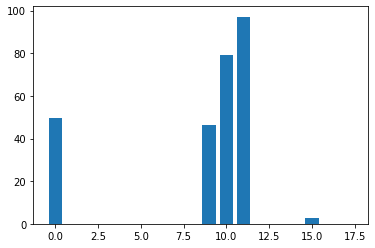

In [47]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot
# define dataset
X, y = make_regression(n_samples=1000, n_features=18, n_informative=5, random_state=1)
# define the model
model = LinearRegression()
# fit the model
model.fit(X, y)
# get importance
importance = model.coef_
# summarize feature importance
for i,v in enumerate(importance):
	print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Churn                    11260 non-null  int64  
 1   Tenure                   11260 non-null  object 
 2   City_Tier                11260 non-null  float64
 3   CC_Contacted_LY          11260 non-null  float64
 4   Payment                  11260 non-null  int32  
 5   Gender                   11260 non-null  int32  
 6   Service_Score            11260 non-null  float64
 7   Account_user_count       11260 non-null  float64
 8   account_segment          11260 non-null  int32  
 9   CC_Agent_Score           11260 non-null  float64
 10  Marital_Status           11260 non-null  int32  
 11  rev_per_month            11260 non-null  float64
 12  Complain_ly              11260 non-null  float64
 13  rev_growth_yoy           11260 non-null  int64  
 14  coupon_used_for_paymen

In [49]:
from sklearn.preprocessing import LabelEncoder   # import label encoder

labelencoder = LabelEncoder()  

df['Gender'] = labelencoder.fit_transform(df.Gender)
df['Payment'] = labelencoder.fit_transform(df.Payment)
df['account_segment'] = labelencoder.fit_transform(df.account_segment)
df['Marital_Status'] = labelencoder.fit_transform(df.Marital_Status) 
df['Login_device'] = labelencoder.fit_transform(df.Login_device)


In [50]:
df.head(10)

,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,1,4.0,3.0,6.0,3,1,3.0,3.0,5,2.0,3,9.0,1.0,11,1.0,5.0,159.93,3
1,1,0.0,1.0,8.0,5,2,3.0,4.0,4,3.0,3,7.0,1.0,15,0.0,0.0,120.90,3
2,1,0.0,1.0,30.0,3,2,2.0,4.0,4,3.0,3,6.0,1.0,14,0.0,3.0,0.00,3
3,1,0.0,3.0,15.0,3,2,2.0,4.0,5,5.0,3,8.0,0.0,23,0.0,3.0,134.07,3
4,1,0.0,1.0,12.0,2,2,2.0,3.0,4,5.0,3,3.0,0.0,11,1.0,3.0,129.60,3
5,1,0.0,1.0,22.0,3,1,3.0,0.0,4,5.0,3,2.0,1.0,22,4.0,7.0,139.19,2
6,1,2.0,3.0,11.0,1,2,2.0,3.0,5,2.0,1,4.0,0.0,14,0.0,0.0,120.86,3
7,1,0.0,1.0,6.0,2,2,3.0,3.0,4,2.0,1,3.0,1.0,16,2.0,0.0,122.93,3
8,1,13.0,3.0,9.0,4,2,2.0,4.0,4,3.0,1,2.0,1.0,14,0.0,2.0,126.83,3
9,1,0.0,1.0,31.0,3,2,2.0,5.0,4,3.0,3,2.0,0.0,12,1.0,1.0,122.93,3


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Churn                    11260 non-null  int64  
 1   Tenure                   11260 non-null  object 
 2   City_Tier                11260 non-null  float64
 3   CC_Contacted_LY          11260 non-null  float64
 4   Payment                  11260 non-null  int64  
 5   Gender                   11260 non-null  int64  
 6   Service_Score            11260 non-null  float64
 7   Account_user_count       11260 non-null  float64
 8   account_segment          11260 non-null  int64  
 9   CC_Agent_Score           11260 non-null  float64
 10  Marital_Status           11260 non-null  int64  
 11  rev_per_month            11260 non-null  float64
 12  Complain_ly              11260 non-null  float64
 13  rev_growth_yoy           11260 non-null  int64  
 14  coupon_used_for_paymen

# 4 Model building - Clear on why was a particular model(s) chosen. - Effort to improve model performance.

In [52]:
x=df.drop('Churn',axis=1)
x

,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,4.0,3.0,6.0,3,1,3.0,3.0,5,2.0,3,9.0,1.0,11,1.0,5.0,159.93,3
1,0.0,1.0,8.0,5,2,3.0,4.0,4,3.0,3,7.0,1.0,15,0.0,0.0,120.90,3
2,0.0,1.0,30.0,3,2,2.0,4.0,4,3.0,3,6.0,1.0,14,0.0,3.0,0.00,3
3,0.0,3.0,15.0,3,2,2.0,4.0,5,5.0,3,8.0,0.0,23,0.0,3.0,134.07,3
4,0.0,1.0,12.0,2,2,2.0,3.0,4,5.0,3,3.0,0.0,11,1.0,3.0,129.60,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11255,10.0,1.0,34.0,2,2,3.0,2.0,5,1.0,2,9.0,0.0,19,1.0,4.0,153.71,2
11256,13.0,1.0,19.0,2,2,3.0,5.0,1,5.0,2,7.0,0.0,16,1.0,8.0,226.91,3
11257,1.0,1.0,14.0,3,2,3.0,2.0,5,4.0,2,7.0,1.0,22,1.0,4.0,191.42,3
11258,23.0,3.0,11.0,2,2,4.0,5.0,5,4.0,2,7.0,0.0,16,2.0,9.0,179.90,2


Feature: 0, Score: 49.47500
Feature: 1, Score: 0.00000
Feature: 2, Score: -0.00000
Feature: 3, Score: -0.00000
Feature: 4, Score: 0.00000
Feature: 5, Score: 0.00000
Feature: 6, Score: 0.00000
Feature: 7, Score: -0.00000
Feature: 8, Score: -0.00000
Feature: 9, Score: 46.40216
Feature: 10, Score: 79.33023
Feature: 11, Score: 97.14084
Feature: 12, Score: 0.00000
Feature: 13, Score: -0.00000
Feature: 14, Score: 0.00000
Feature: 15, Score: 2.54289
Feature: 16, Score: 0.00000
Feature: 17, Score: -0.00000


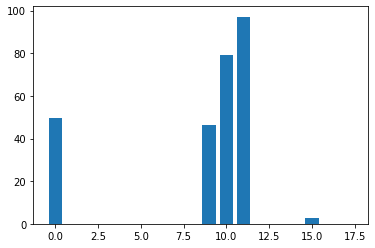

In [53]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot
# define dataset
X, y = make_regression(n_samples=1000, n_features=18, n_informative=5, random_state=1)
# define the model
model = LinearRegression()
# fit the model
model.fit(X, y)
# get importance
importance = model.coef_
# summarize feature importance
for i,v in enumerate(importance):
	print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

In [54]:
y=df['Churn']
y.head

<bound method NDFrame.head of 0        1
1        1
2        1
3        1
4        1
        ..
11255    0
11256    0
11257    0
11258    0
11259    0
Name: Churn, Length: 11260, dtype: int64>

In [55]:
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from imblearn.combine import SMOTEENN

In [56]:
# Split X and y into training and test set in 75:25 ratio
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25 , random_state=1)

### b. Test your predictive model against the test set using various appropriate performance metrics

### Logistic Regression

In [220]:
from sklearn.linear_model import LogisticRegression

In [221]:
model=LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_predict = model.predict(X_test)

In [222]:
y_train_predict=model.predict(X_train)
Logistic_model_score=model.score(X_train,y_train)
print(Logistic_model_score)

print(metrics.confusion_matrix(y_train,y_train_predict))
print(metrics.classification_report(y_train,y_train_predict))

0.8731793960923624
[[6864  159]
 [ 912  510]]
              precision    recall  f1-score   support

           0       0.88      0.98      0.93      7023
           1       0.76      0.36      0.49      1422

    accuracy                           0.87      8445
   macro avg       0.82      0.67      0.71      8445
weighted avg       0.86      0.87      0.85      8445



In [223]:
y_test_predict=model.predict(X_test)
Logistic_model_score=model.score(X_test,y_test)
print(Logistic_model_score)

print(metrics.confusion_matrix(y_test,y_test_predict))
print(metrics.classification_report(y_test,y_test_predict))

0.8785079928952043
[[2288   53]
 [ 289  185]]
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2341
           1       0.78      0.39      0.52       474

    accuracy                           0.88      2815
   macro avg       0.83      0.68      0.73      2815
weighted avg       0.87      0.88      0.86      2815



AUC: 0.854


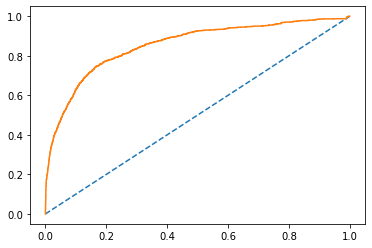

In [224]:
from sklearn.metrics import roc_auc_score,roc_curve
# predict probabilities
probs = model.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_train, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
train_fpr, train_tpr, train_thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(train_fpr, train_tpr);

In [225]:
from sklearn.metrics import accuracy_score

AUC: 0.862


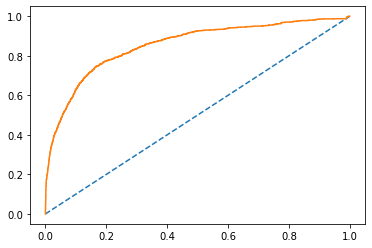

In [56]:
probs_test = model.predict_proba(X_test)

probs_test = probs_test[:, 1]

auc = roc_auc_score(y_test, probs_test)
print('AUC: %.3f' % auc)

test_fpr, test_tpr, test_thresholds = roc_curve(y_test, probs_test)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.plot(train_fpr, train_tpr);

Feature: 0, Score: 49.47500
Feature: 1, Score: 0.00000
Feature: 2, Score: -0.00000
Feature: 3, Score: -0.00000
Feature: 4, Score: 0.00000
Feature: 5, Score: 0.00000
Feature: 6, Score: 0.00000
Feature: 7, Score: -0.00000
Feature: 8, Score: -0.00000
Feature: 9, Score: 46.40216
Feature: 10, Score: 79.33023
Feature: 11, Score: 97.14084
Feature: 12, Score: 0.00000
Feature: 13, Score: -0.00000
Feature: 14, Score: 0.00000
Feature: 15, Score: 2.54289
Feature: 16, Score: 0.00000
Feature: 17, Score: -0.00000


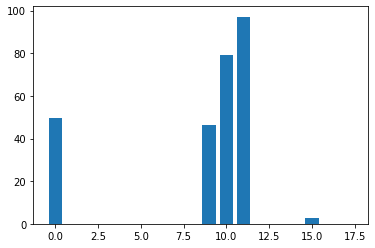

In [57]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot
# define dataset
X, y = make_regression(n_samples=1000, n_features=18, n_informative=5, random_state=1)
# define the model
model = LinearRegression()
# fit the model
model.fit(X, y)
# get importance
importance = model.coef_
# summarize feature importance
for i,v in enumerate(importance):
	print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

In [58]:
from sklearn import linear_model
baseline_lm_mod=linear_model.LogisticRegression(max_iter=1000,penalty='none')
baseline_lm_mod.fit(X_train, y_train)

LogisticRegression(max_iter=1000, penalty='none')

In [59]:
X_train.columns

Index(['Tenure', 'City_Tier', 'CC_Contacted_LY', 'Payment', 'Gender',
       'Service_Score', 'Account_user_count', 'account_segment',
       'CC_Agent_Score', 'Marital_Status', 'rev_per_month', 'Complain_ly',
       'rev_growth_yoy', 'coupon_used_for_payment', 'Day_Since_CC_connect',
       'cashback', 'Login_device'],
      dtype='object')

In [60]:
def get_feature_importance(clf,feature_names):
    feature_importance= (
        pd.DataFrame(
            {
                'variable': feature_names,
                'coefficient':clf.coef_[0]
            }
        )
        
        )
    return feature_importance

In [61]:
get_feature_importance(baseline_lm_mod,X_train.columns)

,variable,coefficient
0,Tenure,-0.129413
1,City_Tier,0.284980
2,CC_Contacted_LY,0.023672
3,Payment,-0.053217
4,Gender,0.250326
5,Service_Score,-0.045049
6,Account_user_count,0.254491
7,account_segment,-0.173601
8,CC_Agent_Score,0.269406
9,Marital_Status,0.503782


### Decision Tree

In [62]:
from sklearn import tree


DT_model= tree.DecisionTreeClassifier(criterion = "gini",random_state = 100,max_depth=6, min_samples_leaf=8)
DT_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=8, random_state=100)

In [63]:
## Performance Matrix on train data set
y_train_predict = DT_model.predict(X_train)
model_score = DT_model.score(X_train, y_train)
print(model_score)
print(metrics.confusion_matrix(y_train, y_train_predict))
print(metrics.classification_report(y_train, y_train_predict,labels=[0,1]))

0.9020722320899941
[[6780  243]
 [ 584  838]]
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7023
           1       0.78      0.59      0.67      1422

    accuracy                           0.90      8445
   macro avg       0.85      0.78      0.81      8445
weighted avg       0.90      0.90      0.90      8445



In [64]:
## Performance Matrix on test data set
y_test_predict = DT_model.predict(X_test)
model_score = DT_model.score(X_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.8920071047957371
[[2249   92]
 [ 212  262]]
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      2341
           1       0.74      0.55      0.63       474

    accuracy                           0.89      2815
   macro avg       0.83      0.76      0.78      2815
weighted avg       0.88      0.89      0.89      2815



### Random Forest

In [240]:
from sklearn.ensemble import RandomForestClassifier

RF_model=RandomForestClassifier(criterion = "gini",random_state = 100,max_depth=7, min_samples_leaf=8)
RF_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, min_samples_leaf=8, random_state=100)

In [241]:
## Performance Matrix on train data set
y_train_predict = RF_model.predict(X_train)
model_score =RF_model.score(X_train, y_train)
print(model_score)
print(metrics.confusion_matrix(y_train, y_train_predict))
print(metrics.classification_report(y_train, y_train_predict))

0.9159265837773831
[[6911  112]
 [ 598  824]]
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7023
           1       0.88      0.58      0.70      1422

    accuracy                           0.92      8445
   macro avg       0.90      0.78      0.83      8445
weighted avg       0.91      0.92      0.91      8445



AUC: 0.958


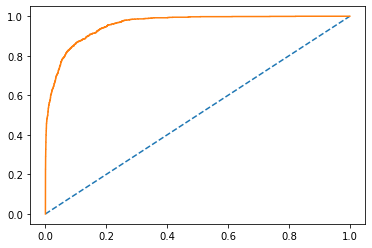

In [242]:
from sklearn.metrics import roc_auc_score,roc_curve
# predict probabilities
probs = RF_model.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_train, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
train_fpr, train_tpr, train_thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(train_fpr, train_tpr);


## Feature importance Random Forest

In [249]:
clf = RandomForestClassifier(n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [250]:
feature_scores = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

feature_scores

Tenure                     0.246458
cashback                   0.081752
CC_Contacted_LY            0.068186
Day_Since_CC_connect       0.068018
Complain_ly                0.063819
rev_growth_yoy             0.060270
CC_Agent_Score             0.055988
rev_per_month              0.055769
Payment                    0.048707
account_segment            0.043689
Marital_Status             0.042733
Account_user_count         0.040331
coupon_used_for_payment    0.032925
City_Tier                  0.027532
Login_device               0.022922
Gender                     0.021205
Service_Score              0.019696
dtype: float64

In [229]:
## Performance Matrix on test data set
y_test_predict = RF_model.predict(X_test)
model_score = RF_model.score(X_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.9108348134991119
[[2295   46]
 [ 205  269]]
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      2341
           1       0.85      0.57      0.68       474

    accuracy                           0.91      2815
   macro avg       0.89      0.77      0.82      2815
weighted avg       0.91      0.91      0.90      2815



AUC: 0.942


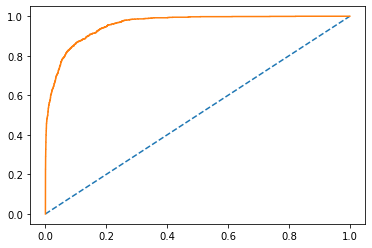

In [232]:
probs_test = RF_model.predict_proba(X_test)

probs_test = probs_test[:, 1]

auc = roc_auc_score(y_test, probs_test)
print('AUC: %.3f' % auc)

test_fpr, test_tpr, test_thresholds = roc_curve(y_test, probs_test)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.plot(train_fpr, train_tpr);

### Naive bayes

In [68]:
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

In [69]:
NB_model = GaussianNB()
NB_model.fit(X_train, y_train)

GaussianNB()

In [70]:
## Performance Matrix on train data set
y_train_predict = NB_model.predict(X_train)
model_score = NB_model.score(X_train, y_train)
print(model_score)
print(metrics.confusion_matrix(y_train, y_train_predict))
print(metrics.classification_report(y_train, y_train_predict))


0.8596802841918295
[[6870  153]
 [1032  390]]
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      7023
           1       0.72      0.27      0.40      1422

    accuracy                           0.86      8445
   macro avg       0.79      0.63      0.66      8445
weighted avg       0.84      0.86      0.83      8445



In [71]:
y_test.value_counts()

0    2341
1     474
Name: Churn, dtype: int64

In [72]:
## Performance Matrix on test data set
y_test_predict = NB_model.predict(X_test)
model_score = NB_model.score(X_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.8596802841918295
[[2284   57]
 [ 338  136]]
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      2341
           1       0.70      0.29      0.41       474

    accuracy                           0.86      2815
   macro avg       0.79      0.63      0.66      2815
weighted avg       0.84      0.86      0.83      2815



# 5 Model validation - How was the model validated ? Just accuracy, or anything else too ?

### Gradient Boosting

In [73]:
from sklearn.ensemble import GradientBoostingClassifier
gbcl = GradientBoostingClassifier(random_state=1)
gbcl = gbcl.fit(X_train, y_train)

In [74]:
## Performance Matrix on train data set
y_train_predict = gbcl.predict(X_train)
model_score = gbcl.score(X_train, y_train)
print(model_score)
print(metrics.confusion_matrix(y_train, y_train_predict))
print(metrics.classification_report(y_train, y_train_predict))

0.9141503848431024
[[6831  192]
 [ 533  889]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7023
           1       0.82      0.63      0.71      1422

    accuracy                           0.91      8445
   macro avg       0.88      0.80      0.83      8445
weighted avg       0.91      0.91      0.91      8445



In [75]:
## Performance Matrix on test data set
y_test_predict = gbcl.predict(X_test)
model_score = gbcl.score(X_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.9119005328596803
[[2280   61]
 [ 187  287]]
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      2341
           1       0.82      0.61      0.70       474

    accuracy                           0.91      2815
   macro avg       0.87      0.79      0.82      2815
weighted avg       0.91      0.91      0.91      2815



### c.Interpretation of the model(s)

# Model Tuning
 

### a.Ensemble modelling, wherever applicable

In [76]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
cart = DecisionTreeClassifier()
Bagging_model=BaggingClassifier(base_estimator=cart,n_estimators=100,max_features=4,random_state=1)
Bagging_model.fit(X_train, y_train)

BaggingClassifier(base_estimator=DecisionTreeClassifier(), max_features=4,
                  n_estimators=100, random_state=1)

In [77]:
## Performance Matrix on train data set
y_train_predict = Bagging_model.predict(X_train)
model_score =Bagging_model.score(X_train, y_train)
print(model_score)
print(metrics.confusion_matrix(y_train, y_train_predict))
print(metrics.classification_report(y_train, y_train_predict))

0.9282415630550621
[[7023    0]
 [ 606  816]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      7023
           1       1.00      0.57      0.73      1422

    accuracy                           0.93      8445
   macro avg       0.96      0.79      0.84      8445
weighted avg       0.93      0.93      0.92      8445



In [78]:
## Performance Matrix on test data set
y_test_predict = Bagging_model.predict(X_test)
model_score = Bagging_model.score(X_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.8458259325044405
[[2341    0]
 [ 434   40]]
              precision    recall  f1-score   support

           0       0.84      1.00      0.92      2341
           1       1.00      0.08      0.16       474

    accuracy                           0.85      2815
   macro avg       0.92      0.54      0.54      2815
weighted avg       0.87      0.85      0.79      2815



ada boost

In [79]:
from sklearn.ensemble import AdaBoostClassifier


ADB_model = AdaBoostClassifier(n_estimators=100,random_state=1)
ADB_model.fit(X_train,y_train)

AdaBoostClassifier(n_estimators=100, random_state=1)

In [80]:
## Performance Matrix on train data set
y_train_predict = ADB_model.predict(X_train)
model_score = ADB_model.score(X_train, y_train)
print(model_score)
print(metrics.confusion_matrix(y_train, y_train_predict))
print(metrics.classification_report(y_train, y_train_predict))

0.8976909413854351
[[6734  289]
 [ 575  847]]
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7023
           1       0.75      0.60      0.66      1422

    accuracy                           0.90      8445
   macro avg       0.83      0.78      0.80      8445
weighted avg       0.89      0.90      0.89      8445



In [81]:
## Performance Matrix on test data set
y_test_predict = ADB_model.predict(X_test)
model_score = ADB_model.score(X_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.8952042628774423
[[2245   96]
 [ 199  275]]
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2341
           1       0.74      0.58      0.65       474

    accuracy                           0.90      2815
   macro avg       0.83      0.77      0.79      2815
weighted avg       0.89      0.90      0.89      2815



In [61]:
from sklearn.model_selection import GridSearchCV

In [62]:
param_grid = {
    'max_depth': [15,20,50],
    'min_samples_leaf': [3, 15],
    'min_samples_split': [10,30],
}

dtr=tree.DecisionTreeRegressor(random_state=123)

grid_search = GridSearchCV(estimator = dtr, param_grid = param_grid, cv = 3)


grid_search.fit(X_train,y_train)

print(grid_search.best_params_)

{'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 10}


### b. Any other model tuning measures(if applicable)

In [63]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn import tree
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [64]:
from sklearn.ensemble import RandomForestRegressor

In [65]:
param_grid = {
    'max_depth': [7,10],
   # 'max_features': [4, 6],
    'min_samples_leaf': [3, 15,30],
    'min_samples_split': [30, 50],
    'n_estimators': [300, 400]
}

rfr = RandomForestRegressor(random_state=123)

grid_search = GridSearchCV(estimator = rfr, param_grid = param_grid, cv = 3,n_jobs=-1)


In [66]:
grid_search.fit(X_train,y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=123), n_jobs=-1,
             param_grid={'max_depth': [7, 10], 'min_samples_leaf': [3, 15, 30],
                         'min_samples_split': [30, 50],
                         'n_estimators': [300, 400]})

In [67]:
print(grid_search.best_params_)

{'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 30, 'n_estimators': 400}


In [68]:
param_grid = {
    'hidden_layer_sizes':[(500),(100,100)], 
    # keeping these simple because it would take too much time to run on low-end computers
    "activation": [ "relu"], 
    "solver": ["sgd", "adam"]}

annr = MLPRegressor(max_iter=10000, random_state=123)

grid_search = GridSearchCV(estimator = annr, param_grid = param_grid, cv = 3)

In [69]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn import tree
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [72]:
ss=StandardScaler() 

x_test_scaled=ss.fit_transform(X_test)

In [73]:
annr = MLPRegressor(hidden_layer_sizes=(500),random_state=123, max_iter=10000)#you are free to tweak the layer sizes
rfr = RandomForestRegressor(random_state=123)
dtr = tree.DecisionTreeRegressor(random_state=123)


models=[dtr,rfr]

rmse_train=[]
rmse_test=[]
scores_train=[]
scores_test=[]

for i in models:  # we are scaling the data for ANN. Without scaling it will give very poor results. Computations becomes easier
    
    if (i != annr) :
        i.fit(X_train,y_train)
        scores_train.append(i.score(X_train, y_train))
        scores_test.append(i.score(X_test, y_test))
        rmse_train.append(np.sqrt(mean_squared_error(y_train,i.predict(X_train))))
        rmse_test.append(np.sqrt(mean_squared_error(y_test,i.predict(X_test))))
 
    else :
        i.fit(X_train,y_train)
        scores_train.append(i.score(X_train, y_train))
        scores_test.append(i.score(X_test, y_test))
        rmse_train.append(np.sqrt(mean_squared_error(y_train,i.predict(X_train))))
        rmse_test.append(np.sqrt(mean_squared_error(y_test,i.predict(X_test))))
        
print(pd.DataFrame({'Train RMSE': rmse_train,'Test RMSE': rmse_test,'Training Score':scores_train,'Test Score': scores_test},
            index=['Decision Tree Regressor','Random Forest Regressor']))

                         Train RMSE  Test RMSE  Training Score  Test Score
Decision Tree Regressor    0.000000   0.247904        1.000000    0.561121
Random Forest Regressor    0.066417   0.166731        0.968499    0.801477


### Random forest is the most optimum model after model building and performing model tunning.  Rest of the part explain in report

# 6 Final interpretation / recommendation - Very clear and crisp on what recommendations do you want to give to the management / client.

### explained in the business report